# Lahore AQI — Exploratory Data Analysis

Before trusting any model, it helps to actually look at the data. This notebook pulls the last 90 days of pollutant and weather readings for Lahore and pokes around for the patterns a forecaster would lean on: how AQI moves over time, when in the day or week it spikes, and which pollutants and weather conditions track it most closely.

It pulls fresh data straight from Open-Meteo, so it stands on its own and doesn't need the feature store to be populated.

In [1]:
import sys
from datetime import date, timedelta
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from data_pipeline.fetch_data import fetch_history
from feature_pipeline.build_features import build_feature_frame
from utils import config

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 4)

In [2]:
end = date.today() - timedelta(days=3)
start = end - timedelta(days=90)
hourly = fetch_history(start.isoformat(), end.isoformat())
print(f'{len(hourly)} hourly rows from {start} to {end}')
hourly.head()

2184 hourly rows from 2026-02-27 to 2026-05-28


,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,aqi
0,2026-02-27 00:00:00,96.2,92.0,1841.0,79.2,21.6,25.0,19.1,55,3.6,982.8,170
1,2026-02-27 01:00:00,101.5,97.3,1453.0,75.1,21.1,24.0,17.8,59,4.5,982.7,173
2,2026-02-27 02:00:00,103.6,99.9,1161.0,70.2,20.3,22.0,17.5,60,2.3,982.6,174
3,2026-02-27 03:00:00,103.6,100.4,1016.0,64.9,18.8,19.0,16.2,65,6.1,982.3,174
4,2026-02-27 04:00:00,102.9,99.9,966.0,58.8,17.1,15.0,15.1,72,4.7,981.8,174


## A first look at the numbers

Quick sanity check on ranges and how dirty the air has been on average.

In [3]:
hourly[['pm2_5', 'pm10', 'ozone', 'nitrogen_dioxide', 'aqi',
        'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m']].describe().round(1)

,pm2_5,pm10,ozone,nitrogen_dioxide,aqi,temperature_2m,relative_humidity_2m,wind_speed_10m
count,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0
mean,39.3,73.9,97.2,26.9,123.2,27.4,47.1,7.1
std,20.9,59.4,53.7,22.9,39.1,6.8,22.5,3.7
min,3.4,6.7,0.0,0.0,48.0,12.4,9.0,0.2
25%,24.0,40.5,53.0,8.2,90.0,22.1,28.0,4.5
50%,33.9,58.1,85.0,21.3,121.0,27.2,44.0,6.5
75%,50.1,85.2,143.2,37.8,154.0,32.5,65.0,9.3
max,119.7,525.3,226.0,114.9,421.0,43.5,100.0,25.8


## How AQI moves over time

The raw hourly signal is noisy, so a 24-hour rolling average makes the underlying trend easier to read.

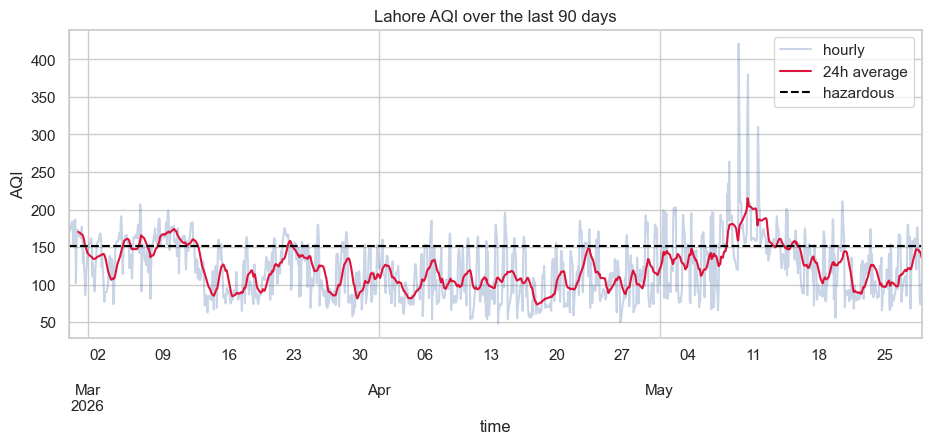

In [4]:
ts = hourly.set_index('time')['aqi']
ax = ts.plot(alpha=0.3, label='hourly')
ts.rolling(24).mean().plot(ax=ax, color='crimson', label='24h average')
ax.axhline(config.HAZARDOUS_AQI_THRESHOLD, ls='--', color='black', label='hazardous')
ax.set_title(f'{config.CITY_NAME} AQI over the last 90 days')
ax.set_ylabel('AQI'); ax.legend(); plt.show()

## Where does AQI usually sit?

The distribution tells us which EPA bands Lahore spends most of its time in.

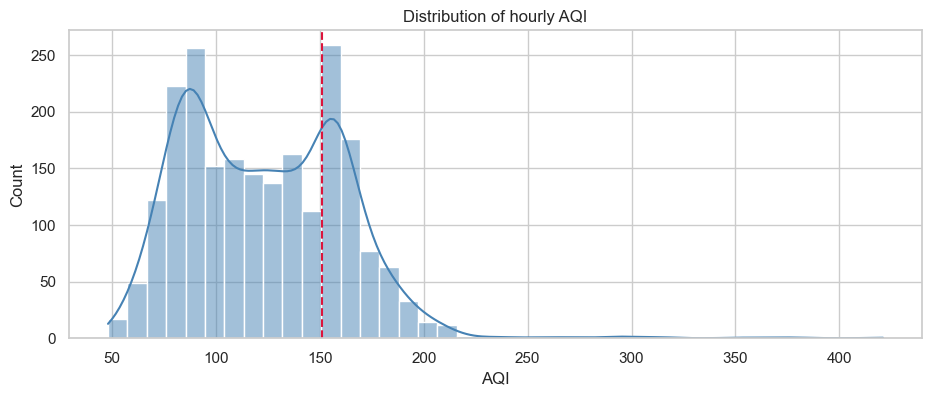

In [5]:
sns.histplot(hourly['aqi'], bins=40, kde=True, color='steelblue')
plt.axvline(config.HAZARDOUS_AQI_THRESHOLD, ls='--', color='crimson')
plt.title('Distribution of hourly AQI'); plt.xlabel('AQI'); plt.show()

## Time-of-day and day-of-week patterns

Pollution tends to breathe with daily routines — traffic peaks, overnight build-up, that sort of thing. These are exactly the time-based signals the feature pipeline encodes.

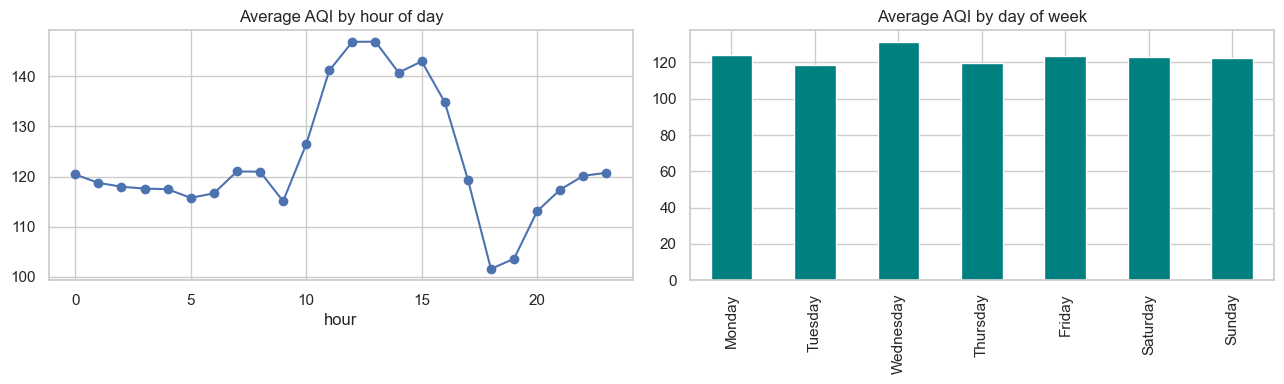

In [6]:
h = hourly.copy()
h['hour'] = h['time'].dt.hour
h['dow'] = h['time'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
h.groupby('hour')['aqi'].mean().plot(ax=axes[0], marker='o')
axes[0].set_title('Average AQI by hour of day'); axes[0].set_xlabel('hour')

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
h.groupby('dow')['aqi'].mean().reindex(order).plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Average AQI by day of week'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

## What correlates with AQI?

A correlation heatmap across pollutants and weather shows which inputs carry the most signal — useful for sanity-checking the model's feature importances later.

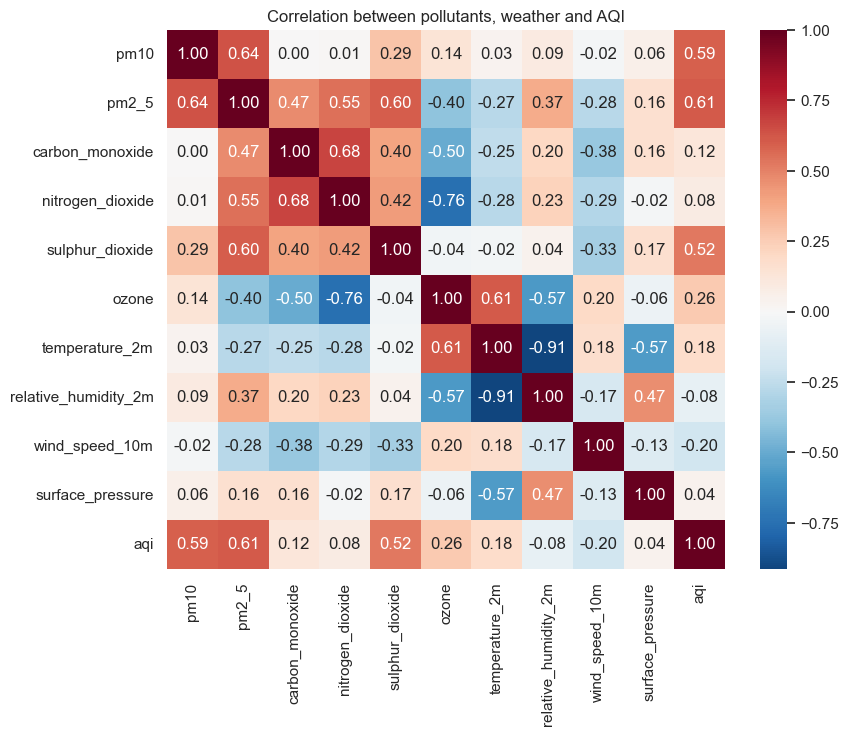

In [7]:
corr_cols = config.AIR_QUALITY_VARS + config.WEATHER_VARS + ['aqi']
corr = hourly[corr_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation between pollutants, weather and AQI'); plt.show()

In [8]:
print('Strongest correlations with AQI:')
corr['aqi'].drop('aqi').sort_values(key=abs, ascending=False).round(3)

Strongest correlations with AQI:


pm2_5                   0.606
pm10                    0.591
sulphur_dioxide         0.522
ozone                   0.261
wind_speed_10m         -0.196
temperature_2m          0.178
carbon_monoxide         0.119
nitrogen_dioxide        0.084
relative_humidity_2m   -0.080
surface_pressure        0.040
Name: aqi, dtype: float64

## Weather vs AQI

Wind tends to clear the air while still, humid conditions trap it. Plotting AQI against a couple of weather variables shows whether that holds here.

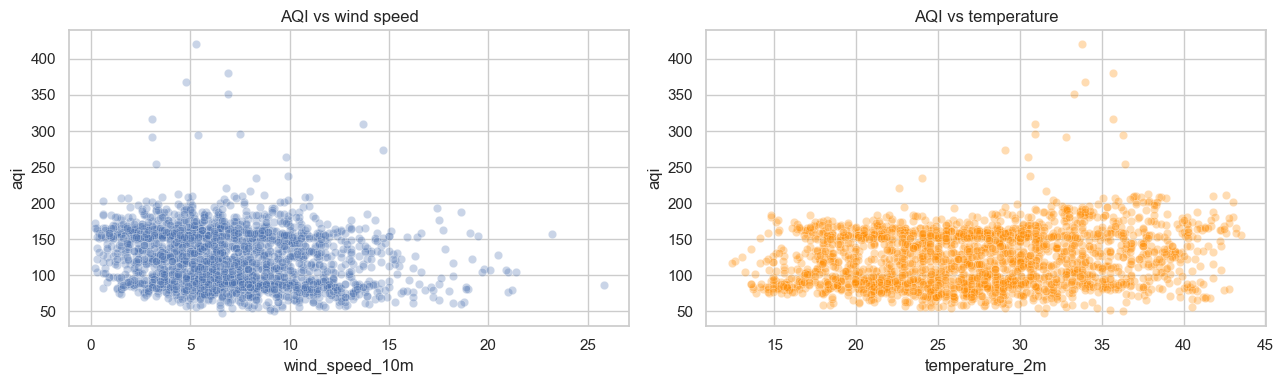

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=hourly, x='wind_speed_10m', y='aqi', alpha=0.3, ax=axes[0])
axes[0].set_title('AQI vs wind speed')
sns.scatterplot(data=hourly, x='temperature_2m', y='aqi', alpha=0.3, ax=axes[1], color='darkorange')
axes[1].set_title('AQI vs temperature')
plt.tight_layout(); plt.show()

## Daily view — what the model actually trains on

The model works at daily resolution, so here's the same data collapsed into the daily feature table, including the engineered lag and rolling features.

In [10]:
daily = build_feature_frame(hourly, drop_incomplete=True)
print(f'{len(daily)} daily rows, {daily.shape[1]} columns')
daily[['date', 'aqi', 'aqi_lag_1', 'aqi_roll_mean_7', 'aqi_change_rate',
       'aqi_next_1', 'aqi_next_2', 'aqi_next_3']].head()

82 daily rows, 35 columns


,date,aqi,aqi_lag_1,aqi_roll_mean_7,aqi_change_rate,aqi_next_1,aqi_next_2,aqi_next_3
0,2026-03-05,147.500000,159.333333,142.982143,-0.074268,162.250000,138.833333,166.958333
1,2026-03-06,162.250000,147.500000,141.845238,0.100000,138.833333,166.958333,171.875000
2,2026-03-07,138.833333,162.250000,141.380952,-0.144325,166.958333,171.875000,158.416667
3,2026-03-08,166.958333,138.833333,145.720238,0.202581,171.875000,158.416667,155.958333
4,2026-03-09,171.875000,166.958333,151.809524,0.029448,158.416667,155.958333,139.541667


## Takeaways

A few things worth carrying into the modelling:

- **AQI is sticky.** Today's value is a strong hint about tomorrow's, which is why the lag and rolling-mean features earn their place.
- **PM2.5 and PM10 dominate** the AQI here — they show the tightest correlation with the index, matching the fact that particulates are usually the worst offender in Lahore.
- **Wind helps, stillness hurts.** Higher wind speeds line up with cleaner air.
- **There's a daily rhythm**, so the hour/day/month time features give the model something real to grab onto.

All of which says a feature-based regressor on recent history is a reasonable bet for a 3-day-ahead forecast.